**Importing libraries for Data Loading, cleaining and visualization**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Data Loading**

In [2]:
df = pd.read_csv('ml-track-data/train.csv', index_col=0)
test_df = pd.read_csv('ml-track-data/test.csv', index_col=0)

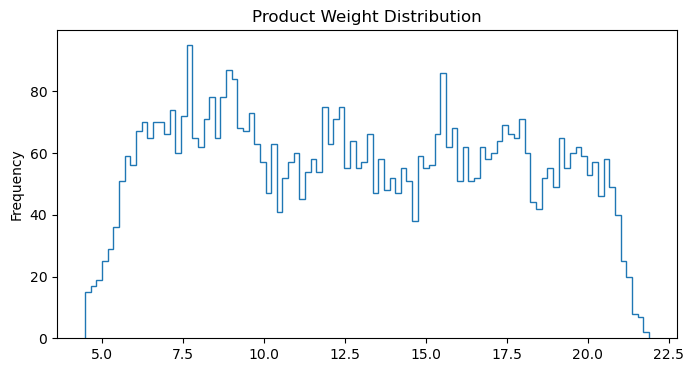

In [3]:
df['product_weight_kg'].plot(kind='hist', bins=100, figsize=(8, 4), histtype='step')
plt.title('Product Weight Distribution')
plt.show()

**EDA & Data Cleaning**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6818 entries, row_00000 to row_08522
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         6818 non-null   object 
 1   product_weight_kg    5593 non-null   float64
 2   fat_content          6818 non-null   object 
 3   shelf_visibility     6818 non-null   float64
 4   product_category     6818 non-null   object 
 5   product_price        6818 non-null   float64
 6   store_code           6818 non-null   object 
 7   store_age_years      6818 non-null   int64  
 8   store_size           4899 non-null   object 
 9   store_location_tier  6818 non-null   object 
 10  store_format         6818 non-null   object 
 11  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 950.5+ KB


In [5]:
df.describe(include='all')

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
count,6818,5593.000000,6818,6818.000000,6818,6818.000000,6818,6818.000000,4899,6818,6818,6818.000000
unique,1555,NaN,2,NaN,48,NaN,10,NaN,3,3,4,NaN
top,PRD-YZB4K8,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,STORE-YLW,NaN,Medium,Tier_3,Standard Supermarket,NaN
freq,9,NaN,4425,NaN,480,NaN,754,NaN,2218,2677,4462,NaN
mean,NaN,12.850876,NaN,0.065527,NaN,140.473623,NaN,34.178205,NaN,NaN,NaN,2174.756574
std,NaN,4.646542,NaN,0.051566,NaN,62.413513,NaN,8.384574,NaN,NaN,NaN,1697.894956
min,NaN,4.482000,NaN,0.000000,NaN,31.110000,NaN,23.000000,NaN,NaN,NaN,32.700000
25%,NaN,8.750000,NaN,0.026600,NaN,93.280000,NaN,28.000000,NaN,NaN,NaN,834.792500
50%,NaN,12.647000,NaN,0.053200,NaN,142.065000,NaN,33.000000,NaN,NaN,NaN,1790.890000
75%,NaN,16.894000,NaN,0.093400,NaN,185.987500,NaN,45.000000,NaN,NaN,NaN,3092.587500


### from the basic informations, the dataset has 12 colums **(Excluding the ID column)**
#### There are:
1. **5** Numerical Features (product_weight_kg, shelf_visibility, product_price, store_age_year)
2. **7** Categorical Features (product_code, fat_content, product_category, store_code, store_size, store_location_tier, store_format)

#### Out of which:
3. **2** Features (product_weight_kg, store_size) have null values

In [6]:
df.sample(5)

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
id,,,,,,,,,,,,
row_06382,PRD-BJD8BL,9.606,Regular,0.0588,BREADS,86.40,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,1768.13
row_02664,PRD-Y7T0DJ,14.019,Low Fat,0.1269,FRUITS AND VEGETABLES,87.60,STORE-HL7,23,Medium,Tier_3,Superstore,1143.25
row_04447,PRD-9VW3RT,18.472,Low Fat,0.0149,HARD DRINKS,107.00,STORE-9RG,28,Small,Tier_2,Standard Supermarket,1953.06
row_05931,PRD-2VTJXU,6.352,Low Fat,0.1250,fruits and vegetables,45.33,STORE-DKU,30,NaN,Tier_2,Standard Supermarket,811.28
row_00575,PRD-F7NY03,16.803,Regular,0.0537,frozen foods,113.94,STORE-9RG,28,Small,Tier_2,Standard Supermarket,1504.27


In [7]:
df['product_category'].nunique()

48

In [8]:
df['product_category'].value_counts()

product_category
Fruits and Vegetables    480
Snack Foods              468
Household                387
Frozen Foods             326
Canned                   271
Dairy                    269
fruits and vegetables    265
FRUITS AND VEGETABLES    261
Baking Goods             254
snack foods              236
SNACK FOODS              229
Health and Hygiene       197
HOUSEHOLD                185
Soft Drinks              178
frozen foods             177
FROZEN FOODS             172
household                168
Meat                     157
DAIRY                    143
dairy                    142
BAKING GOODS             137
canned                   129
baking goods             125
CANNED                   117
health and hygiene       116
Breads                   110
SOFT DRINKS              100
HEALTH AND HYGIENE        99
MEAT                      94
Hard Drinks               92
meat                      88
soft drinks               88
Others                    73
Starchy Foods             

#### There is inconsistencies in the product_category Feature (Error in Text Casing)

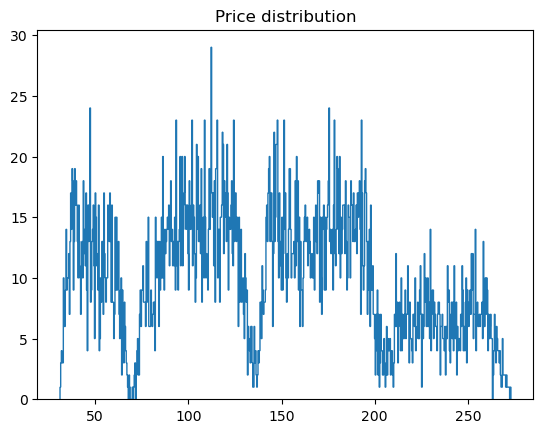

In [9]:
plt.hist(df['product_price'], bins = 681, histtype = 'step')
plt.title('Price distribution')
plt.show()

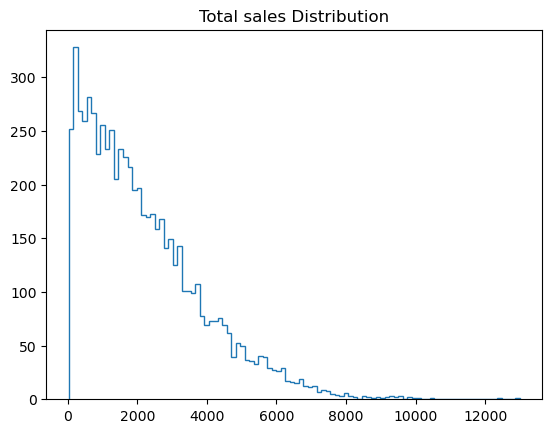

In [10]:
plt.hist(df['total_sales'], bins = 100, histtype = 'step')
plt.title('Total sales Distribution')
plt.show()

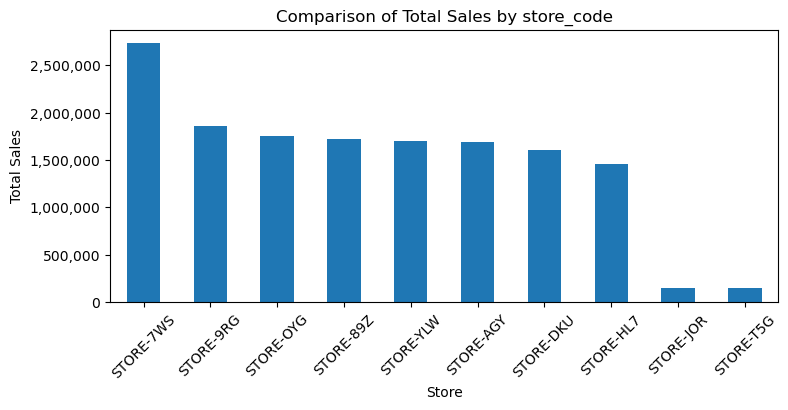

In [11]:
from matplotlib.ticker import StrMethodFormatter

ax = (
    df.groupby('store_code')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .plot(kind='bar', figsize=(8, 4))
)

ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.ylabel('Total Sales')
plt.xlabel('Store')
plt.xticks(rotation=45)
plt.tight_layout()
plt.title('Comparison of Total Sales by store_code')
plt.show()

In [12]:
# Fixing the Data inconsistency in product_category Feature

df['product_category'] = df['product_category'].str.title()
test_df['product_category'] = test_df['product_category'].str.title()
df['product_category'].value_counts()

product_category
Fruits And Vegetables    1006
Snack Foods               933
Household                 740
Frozen Foods              675
Dairy                     554
Canned                    517
Baking Goods              516
Health And Hygiene        412
Soft Drinks               366
Meat                      339
Breads                    209
Hard Drinks               169
Others                    132
Starchy Foods             113
Breakfast                  85
Seafood                    52
Name: count, dtype: int64

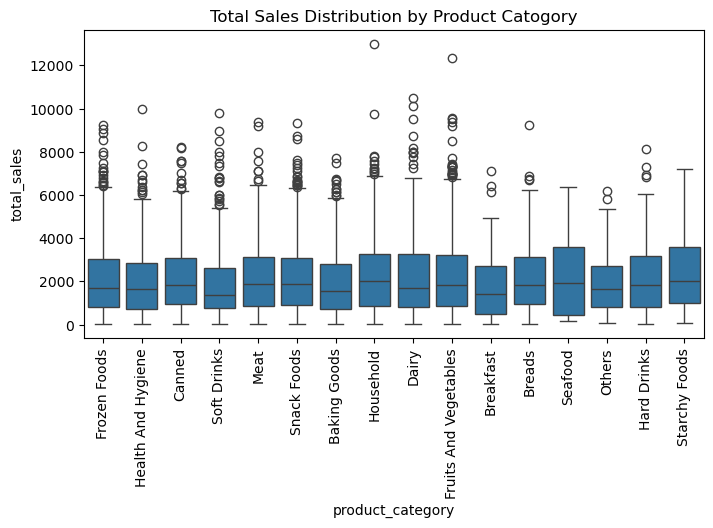

In [13]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x='product_category',
    y='total_sales'
)

plt.xticks(rotation=90)
plt.title('Total Sales Distribution by Product Catogory')
plt.show()

In [14]:
# Invesigating the Null Values in the store_size Feature and also finding the best solution to the problem

# To identify similarities between the stores and their stores size as well as other store properties
stores_inspection = df.groupby('store_code').agg({
    'store_size': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'store_location_tier': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'store_age_years': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'total_sales': 'sum',
    'store_format': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'product_category': 'nunique',
    'product_code': 'nunique'
})
stores_inspection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, STORE-7WS to STORE-YLW
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   store_size           7 non-null      object 
 1   store_location_tier  10 non-null     object 
 2   store_age_years      10 non-null     int64  
 3   total_sales          10 non-null     float64
 4   store_format         10 non-null     object 
 5   product_category     10 non-null     int64  
 6   product_code         10 non-null     int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 640.0+ bytes


In [15]:
stores_inspection

,store_size,store_location_tier,store_age_years,total_sales,store_format,product_category,product_code
store_code,,,,,,,
STORE-7WS,Medium,Tier_3,47,2737816.30,Flagship Hypermarket,16,748
STORE-89Z,Medium,Tier_1,33,1722394.67,Standard Supermarket,16,728
STORE-9RG,Small,Tier_2,28,1864334.41,Standard Supermarket,16,752
STORE-AGY,Large,Tier_3,45,1686657.81,Standard Supermarket,16,748
STORE-DKU,NaN,Tier_2,30,1602372.45,Standard Supermarket,16,736
STORE-HL7,Medium,Tier_3,23,1462973.17,Superstore,16,742
STORE-JOR,NaN,Tier_3,34,146816.97,Corner Shop,16,439
STORE-OYG,NaN,Tier_2,25,1760180.24,Standard Supermarket,16,744
STORE-T5G,Small,Tier_1,47,144465.48,Corner Shop,16,427


In [16]:
null_percent = ((
    stores_inspection.loc[
        stores_inspection['store_size'].isna(),
        'product_code'
    ].sum()
) / stores_inspection['product_code'].sum()) * 100

null_percent = null_percent.round(2)
null_percent

np.float64(28.15)

There are 10 unique stores in the data, but only three of them have Null store size values **(~28.1% of the data has null store_size)**

In [17]:
stores_inspection['average_total_sales'] = stores_inspection['total_sales']/stores_inspection['product_code'].count()
stores_inspection['average_total_sales'] = stores_inspection['average_total_sales'].round(2)

In [18]:
stores_inspection

,store_size,store_location_tier,store_age_years,total_sales,store_format,product_category,product_code,average_total_sales
store_code,,,,,,,,
STORE-7WS,Medium,Tier_3,47,2737816.30,Flagship Hypermarket,16,748,273781.63
STORE-89Z,Medium,Tier_1,33,1722394.67,Standard Supermarket,16,728,172239.47
STORE-9RG,Small,Tier_2,28,1864334.41,Standard Supermarket,16,752,186433.44
STORE-AGY,Large,Tier_3,45,1686657.81,Standard Supermarket,16,748,168665.78
STORE-DKU,NaN,Tier_2,30,1602372.45,Standard Supermarket,16,736,160237.24
STORE-HL7,Medium,Tier_3,23,1462973.17,Superstore,16,742,146297.32
STORE-JOR,NaN,Tier_3,34,146816.97,Corner Shop,16,439,14681.70
STORE-OYG,NaN,Tier_2,25,1760180.24,Standard Supermarket,16,744,176018.02
STORE-T5G,Small,Tier_1,47,144465.48,Corner Shop,16,427,14446.55


#### From this inspection, i was able to find out that
1. STORE-JOR has similar properties to STORE-T5G in terms of amount of products sold, average_total_sales, store_format therefore **I filled its Store_size Null values with Small**
2. Both STORE-OYG and STORE-DKU has similar properties with the Medium sized Stores in terms of the products sold, total sales, average_total_sales etc **I filled its Store_size Null values with Medium**

In [19]:
# replacing the store_size Null values with the infered size from the data
df.loc[
    df['store_size'].isna() &
    df['store_code'].isin(['STORE-OYG', 'STORE-DKU']),
    'store_size'
] = 'Medium'
df.loc[
    df['store_size'].isna() &
    df['store_code'].isin(['STORE-JOR']),
    'store_size'
] = 'Small'


test_df.loc[
    test_df['store_size'].isna() &
    test_df['store_code'].isin(['STORE-OYG', 'STORE-DKU']),
    'store_size'
] = 'Medium'
test_df.loc[
    test_df['store_size'].isna() &
    test_df['store_code'].isin(['STORE-JOR']),
    'store_size'
] = 'Small'

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6818 entries, row_00000 to row_08522
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         6818 non-null   object 
 1   product_weight_kg    5593 non-null   float64
 2   fat_content          6818 non-null   object 
 3   shelf_visibility     6818 non-null   float64
 4   product_category     6818 non-null   object 
 5   product_price        6818 non-null   float64
 6   store_code           6818 non-null   object 
 7   store_age_years      6818 non-null   int64  
 8   store_size           6818 non-null   object 
 9   store_location_tier  6818 non-null   object 
 10  store_format         6818 non-null   object 
 11  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 950.5+ KB


#### Inspecting the product_weight_kg in other to handle its null values

In [21]:
null_weights = df.loc[
    df['product_weight_kg'].isna()
]

null_weights.sample(10)

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
id,,,,,,,,,,,,
row_02972,PRD-WKDRX0,NaN,Regular,0.0597,Meat,44.36,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,781.89
row_04626,PRD-G05TPN,NaN,Low Fat,0.0766,Household,192.17,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5634.11
row_03555,PRD-HYS3T2,NaN,Low Fat,0.0699,Snack Foods,122.32,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4132.71
row_01005,PRD-Q8V88B,NaN,Regular,0.1036,Canned,230.09,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5621.86
row_07295,PRD-9LB7L5,NaN,Regular,0.1746,Dairy,160.43,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4529.97
row_02384,PRD-W80O9D,NaN,Low Fat,0.0000,Frozen Foods,226.41,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4349.91
row_00261,PRD-0G6HSH,NaN,Regular,0.0807,Baking Goods,151.46,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,1853.64
row_03176,PRD-J5S6R0,NaN,Regular,0.0447,Dairy,147.54,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,3470.43
row_07331,PRD-NDSUDE,NaN,Regular,0.0382,Fruits And Vegetables,106.18,STORE-DKU,30,Medium,Tier_2,Standard Supermarket,901.01


In [22]:
null_weights.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1225 entries, row_00003 to row_08514
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         1225 non-null   object 
 1   product_weight_kg    0 non-null      float64
 2   fat_content          1225 non-null   object 
 3   shelf_visibility     1225 non-null   float64
 4   product_category     1225 non-null   object 
 5   product_price        1225 non-null   float64
 6   store_code           1225 non-null   object 
 7   store_age_years      1225 non-null   int64  
 8   store_size           1225 non-null   object 
 9   store_location_tier  1225 non-null   object 
 10  store_format         1225 non-null   object 
 11  total_sales          1225 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 124.4+ KB


In [23]:
null_weight_percent = (
    df['product_weight_kg'].isna().sum()
    / len(df)
) * 100

null_weight_percent = null_weight_percent.round(2)
print(null_weight_percent)

17.97


#### ~17.9% of the data has null product_weight_kg.

In [48]:
df['product_weight_kg'] = df.groupby(['product_category', 'product_code'])['product_weight_kg'].transform(lambda x: x.fillna(x.median())) 
test_df['product_weight_kg'] = test_df.groupby(['product_category', 'product_code'])['product_weight_kg'].transform(lambda x: x.fillna(x.median()))


#fallback
df['product_weight_kg'] = df.groupby(['product_category'])['product_weight_kg'].transform(lambda x: x.fillna(x.median())) 
test_df['product_weight_kg'] = test_df.groupby(['product_category'])['product_weight_kg'].transform(lambda x: x.fillna(x.median()))

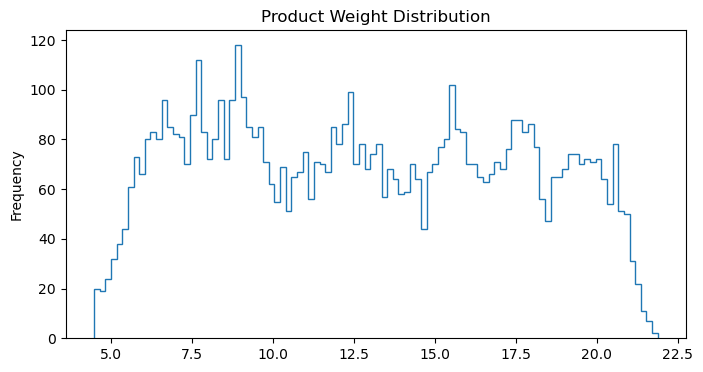

In [49]:
df['product_weight_kg'].plot(kind='hist', bins=100, figsize=(8, 4), histtype='step')
plt.title('Product Weight Distribution')
plt.show()

In [50]:
df.describe(include='all')

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
count,6818,6818.000000,6818,6818.000000,6818,6818.000000,6818,6818.000000,6818,6818,6818,6818.000000
unique,1555,NaN,2,NaN,16,NaN,10,NaN,3,3,4,NaN
top,PRD-YZB4K8,NaN,Low Fat,NaN,Fruits And Vegetables,NaN,STORE-YLW,NaN,Medium,Tier_3,Standard Supermarket,NaN
freq,9,NaN,4425,NaN,1006,NaN,754,NaN,3698,2677,4462,NaN
mean,NaN,12.869335,NaN,0.065527,NaN,140.473623,NaN,34.178205,NaN,NaN,NaN,2174.756574
std,NaN,4.642579,NaN,0.051566,NaN,62.413513,NaN,8.384574,NaN,NaN,NaN,1697.894956
min,NaN,4.482000,NaN,0.000000,NaN,31.110000,NaN,23.000000,NaN,NaN,NaN,32.700000
25%,NaN,8.784000,NaN,0.026600,NaN,93.280000,NaN,28.000000,NaN,NaN,NaN,834.792500
50%,NaN,12.695500,NaN,0.053200,NaN,142.065000,NaN,33.000000,NaN,NaN,NaN,1790.890000
75%,NaN,16.922000,NaN,0.093400,NaN,185.987500,NaN,45.000000,NaN,NaN,NaN,3092.587500


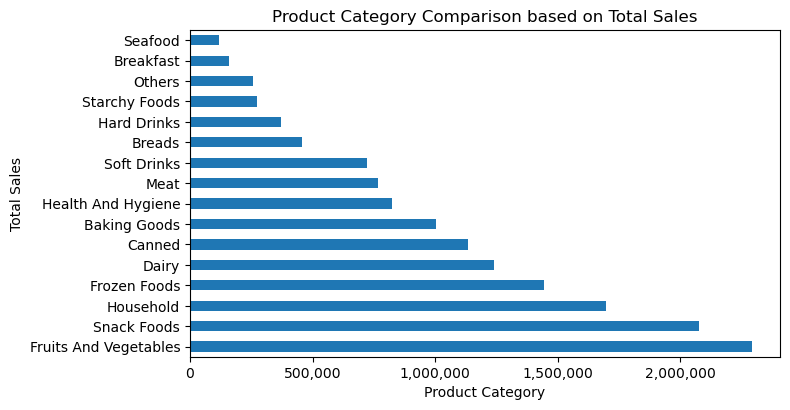

In [51]:
ax = (
    df.groupby('product_category')['total_sales']
      .sum()
      .sort_values(ascending=False)
      .plot(kind='barh', figsize=(8, 4))
)

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.ylabel('Total Sales')
plt.xlabel('Product Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.title('Product Category Comparison based on Total Sales')
plt.show()

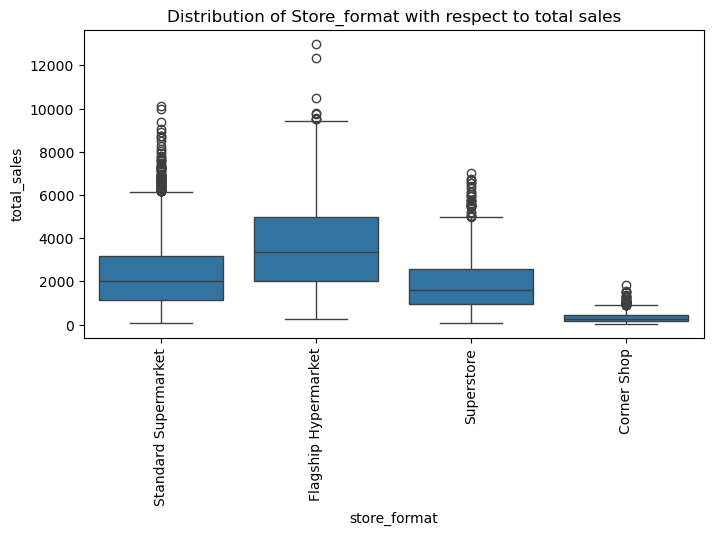

In [52]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x='store_format',
    y='total_sales'
)

plt.xticks(rotation=90)
plt.title('Distribution of Store_format with respect to total sales')
plt.show()

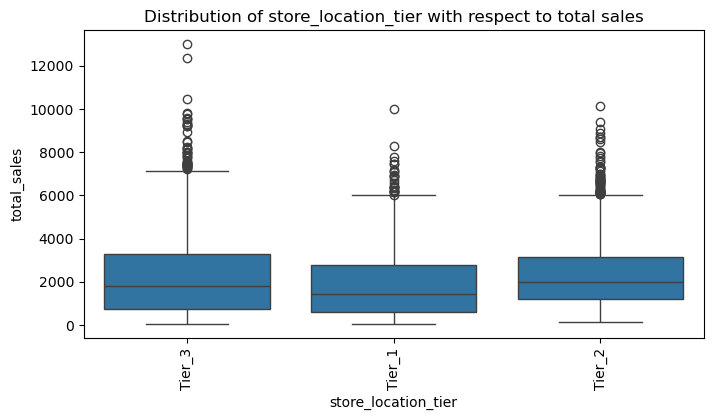

In [53]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x='store_location_tier',
    y='total_sales'
)

plt.xticks(rotation=90)
plt.title('Distribution of store_location_tier with respect to total sales')
plt.show()

In [54]:
df.corr(numeric_only=True)

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
product_weight_kg,1.000000,-0.011527,0.030216,0.010651,0.014136
shelf_visibility,-0.011527,1.000000,0.003905,0.071078,-0.118124
product_price,0.030216,0.003905,1.000000,-0.012747,0.569833
store_age_years,0.010651,0.071078,-0.012747,1.000000,0.039443
total_sales,0.014136,-0.118124,0.569833,0.039443,1.000000


### EDA Results
1. There are Data Inconsistencies in the product_category Feature which was handled using proper text formatting
2. There are Null values in the store_format and the product_weight_kg, which wew handled professionally after analysis
3. Total Sales is greatly influenced by store_format 
4. Total Sales Distribution is Right Skewed indicating Decrease in sales as price inceases.
5. Flagship Hypermarkets and Super store has Higher Sales
6. Corner Stores has Relatively Lower Sales
7. Fruit and Vegetables is the most Purchased Product Cateory followed snack foods and Household products respectively
8. Seafoods is the Least Purchased Product Category.

### Feature Engineering

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6818 entries, row_00000 to row_08522
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         6818 non-null   object 
 1   product_weight_kg    6818 non-null   float64
 2   fat_content          6818 non-null   object 
 3   shelf_visibility     6818 non-null   float64
 4   product_category     6818 non-null   object 
 5   product_price        6818 non-null   float64
 6   store_code           6818 non-null   object 
 7   store_age_years      6818 non-null   int64  
 8   store_size           6818 non-null   object 
 9   store_location_tier  6818 non-null   object 
 10  store_format         6818 non-null   object 
 11  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 950.5+ KB


In [56]:
# Features engineering

def feature_engineer(df):
    df = df.copy()

    # price range indicator: to indicate how expensive a product is among its category per store
    df['price_position'] = (
        df.groupby(['product_category', 'product_code'])['product_price']
          .transform(
          lambda x: pd.qcut(
              x,
              q=3,
              labels=False,
              duplicates='drop'
          )
      ).fillna(1)
    )

    
    # Price Per Product_weight_kg
    df['price_per_kg'] = df['product_price'] * df['product_weight_kg']

    # Product_Category per Store price relationship
    df['category_average_price/store'] = df.groupby(['product_category', 'store_code'])['product_price'].transform('mean')
    df['relative_category_price'] = df['product_price'] / df['category_average_price/store']

    # Product per Store price relationship
    df['product_average_price/store'] = df.groupby(['product_code'])['product_price'].transform('mean')
    df['relative_product_price'] = df['product_price'] / df['product_average_price/store']

    return df



train = feature_engineer(df)
test = feature_engineer(test_df)


In [57]:
# --- TARGET ENCODING: Store-level and Category-level statistics ---
# WHY: Some stores consistently sell more than others.
#  Encoding this gives the model a "baseline" for each store.

# Store-level mean sales
store_mean_sales = train.groupby('store_code')['total_sales'].mean()
train['store_mean_sales'] = train['store_code'].map(store_mean_sales)
test['store_mean_sales'] = test['store_code'].map(store_mean_sales)

# Store-level median sales (more robust to outliers)
store_median_sales = train.groupby('store_code')['total_sales'].median()
train['store_median_sales'] = train['store_code'].map(store_median_sales)
test['store_median_sales'] = test['store_code'].map(store_median_sales)

# Category-level mean sales
cat_mean_sales = train.groupby('product_category')['total_sales'].mean()
train['category_mean_sales'] = train['product_category'].map(cat_mean_sales)
test['category_mean_sales'] = test['product_category'].map(cat_mean_sales)

# Fill any NAs (categories in test not in train)
for col in ['store_mean_sales', 'store_median_sales', 'category_mean_sales']:
 train[col].fillna(train['total_sales'].mean(), inplace=True)
 test[col].fillna(train['total_sales'].mean(), inplace=True)

print(" Target encoding complete!")
print(f"\nStore mean sales:")
for store, mean_val in store_mean_sales.sort_values(ascending=False).items():
 print(f" {store}: ₦{mean_val:,.2f}")

 Target encoding complete!

Store mean sales:
 STORE-7WS: ₦3,660.18
 STORE-9RG: ₦2,479.17
 STORE-89Z: ₦2,365.93
 STORE-OYG: ₦2,365.83
 STORE-AGY: ₦2,254.89
 STORE-YLW: ₦2,253.95
 STORE-DKU: ₦2,177.14
 STORE-HL7: ₦1,971.66
 STORE-T5G: ₦338.33
 STORE-JOR: ₦334.44


C:\Users\DELL\AppData\Local\Temp\ipykernel_27284\1658343066.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train['total_sales'].mean(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_27284\1658343066.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [58]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6818 entries, row_00000 to row_08522
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_code                  6818 non-null   object 
 1   product_weight_kg             6818 non-null   float64
 2   fat_content                   6818 non-null   object 
 3   shelf_visibility              6818 non-null   float64
 4   product_category              6818 non-null   object 
 5   product_price                 6818 non-null   float64
 6   store_code                    6818 non-null   object 
 7   store_age_years               6818 non-null   int64  
 8   store_size                    6818 non-null   object 
 9   store_location_tier           6818 non-null   object 
 10  store_format                  6818 non-null   object 
 11  total_sales                   6818 non-null   float64
 12  price_position                6818 non-null   float64


In [59]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1705 entries, row_00009 to row_08515
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_code                  1705 non-null   object 
 1   product_weight_kg             1705 non-null   float64
 2   fat_content                   1705 non-null   object 
 3   shelf_visibility              1705 non-null   float64
 4   product_category              1705 non-null   object 
 5   product_price                 1705 non-null   float64
 6   store_code                    1705 non-null   object 
 7   store_age_years               1705 non-null   int64  
 8   store_size                    1705 non-null   object 
 9   store_location_tier           1705 non-null   object 
 10  store_format                  1705 non-null   object 
 11  price_position                1705 non-null   float64
 12  price_per_kg                  1705 non-null   float64


In [60]:
train.sample(10)

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,...,total_sales,price_position,price_per_kg,category_average_price/store,relative_category_price,product_average_price/store,relative_product_price,store_mean_sales,store_median_sales,category_mean_sales
id,,,,,,,,,,,,,,,,,,,,,
row_03390,PRD-NSQDTZ,17.134,Low Fat,0.0498,Snack Foods,115.12,STORE-HL7,23,Medium,Tier_3,...,2806.27,1.0,1972.46608,143.865051,0.800194,114.971667,1.001290,1971.661954,1622.170,2223.830568
row_01444,PRD-9AHEJ8,8.952,Low Fat,0.1015,Dairy,41.90,STORE-YLW,35,Small,Tier_1,...,710.03,1.0,375.08880,144.594030,0.289777,41.246000,1.015856,2253.950690,1902.455,2238.317076
row_06303,PRD-11CMKR,11.773,Low Fat,0.0347,Canned,178.30,STORE-OYG,25,Medium,Tier_2,...,5233.87,0.0,2099.12590,137.830167,1.293621,181.252000,0.983713,2365.833656,2018.895,2196.398743
row_02526,PRD-PCUYHY,15.028,Low Fat,0.0978,Baking Goods,160.69,STORE-9RG,28,Small,Tier_2,...,2744.51,2.0,2414.84932,121.610727,1.321347,157.891667,1.017723,2479.168098,2139.320,1943.416860
row_01398,PRD-EWQGAD,5.467,Regular,0.0321,Canned,189.83,STORE-OYG,25,Medium,Tier_2,...,3218.20,1.0,1037.80061,137.830167,1.377275,190.231667,0.997889,2365.833656,2018.895,2196.398743
row_05772,PRD-UHT6T0,15.963,Low Fat,0.0327,Soft Drinks,72.84,STORE-DKU,30,Medium,Tier_2,...,884.41,0.0,1162.74492,128.121220,0.568524,73.888333,0.985812,2177.136481,1863.030,1967.399454
row_00278,PRD-PTOMJB,8.005,Low Fat,0.0358,Soft Drinks,169.93,STORE-YLW,35,Small,Tier_1,...,2649.46,0.0,1360.28965,130.434750,1.302797,173.492000,0.979469,2253.950690,1902.455,1967.399454
row_06921,PRD-IALDTG,5.765,Low Fat,0.1693,Baking Goods,147.10,STORE-JOR,34,Small,Tier_3,...,445.58,1.0,848.03150,124.275000,1.183665,147.130000,0.999796,334.435011,240.320,1943.416860
row_01691,PRD-ANEC1W,6.239,Low Fat,0.0123,Fruits And Vegetables,38.67,STORE-AGY,45,Large,Tier_3,...,501.31,2.0,241.26213,142.240887,0.271863,37.738000,1.024697,2254.890120,1998.725,2277.854672


In [61]:
train['price_position'].value_counts()

price_position
0.0    2763
2.0    2267
1.0    1788
Name: count, dtype: int64

In [69]:
X_train = train.drop(columns=['total_sales', 'fat_content']).copy()
y_train = train['total_sales'].copy()

X_test = test.drop(columns=['fat_content']).copy()


In [70]:
X_test.shape[1]

19

In [71]:
X_train.shape[1]

19

In [65]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

categorical_features = [
    'product_code',
    'product_category',
    'store_code',
    'store_size',
    'store_location_tier',
    'store_format'
]

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=0
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, validation_index in kf.split(X_train):

    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[validation_index]

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    predictions = model.predict(X_fold_valid)

    rmse = np.sqrt(np.mean((y_fold_valid - predictions) ** 2))

    scores.append(rmse)

    print(f"Fold RMSE: {rmse:.4f}")

print("\nCross-validation results")
print(f"RMSE scores: {scores}")
print(f"Mean RMSE: {np.mean(scores):.4f}")
print(f"Std RMSE: {np.std(scores):.4f}")

Fold RMSE: 1065.8698
Fold RMSE: 1050.9190
Fold RMSE: 1089.1962
Fold RMSE: 1102.6975
Fold RMSE: 1069.4322

Cross-validation results
RMSE scores: [np.float64(1065.8697621761557), np.float64(1050.9189903269018), np.float64(1089.1961909048105), np.float64(1102.697539979793), np.float64(1069.4322310662178)]
Mean RMSE: 1075.6229
Std RMSE: 18.2264


In [66]:
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=100
)

final_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

y_pred = final_model.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})
submission_df.to_csv('submission_cv_v11_1.csv', index=False)

0:	learn: 1678.5756215	total: 125ms	remaining: 1m 2s
100:	learn: 1092.0542880	total: 10.9s	remaining: 43.1s
200:	learn: 1057.0712646	total: 17.9s	remaining: 26.6s
300:	learn: 1045.5022537	total: 24.1s	remaining: 16s
400:	learn: 1036.1847528	total: 30.3s	remaining: 7.48s
499:	learn: 1026.2139514	total: 36.7s	remaining: 0us


In [72]:
from sklearn.model_selection import RandomizedSearchCV, KFold

# Categorical features
categorical_features = [
    'product_code',
    'product_category',
    'store_code',
    'store_size',
    'store_location_tier',
    'store_format'
]

# Base CatBoost model
model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=62,
    verbose=0
)

# Hyperparameter search space
param_grid = {
    'iterations': [300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05],
    'depth': [5, 6, 7, 8],
    'l2_leaf_reg': [3, 5, 7, 10]
}

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Randomized hyperparameter search
search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=kf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run hyperparameter tuning
search.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

# Best parameters
print("Best Parameters:")
print(search.best_params_)

# Best cross-validation RMSE
print("\nBest CV RMSE:")
print(-search.best_score_)

# Best trained model
best_model = search.best_estimator_

# Predictions
predictions = best_model.predict(X_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 700, 'depth': 6}

Best CV RMSE:
1073.3512312426024


In [ ]:
final_model = CatBoostRegressor(
    iterations=700,
    learning_rate=0.01,
    depth=6,
    l2_leaf_reg: 7,
    loss_function='RMSE',
    random_seed=62,
    verbose=100
)

final_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

y_pred = final_model.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})
submission_df.to_csv('submission_cv_v11_1.csv', index=False)

Encoding

In [67]:
import category_encoders as ce


# ============================================================
# 2. Ordinal Encoding
# ============================================================

categories = {
    'store_size': ['Small', 'Medium', 'Large'],
    'store_location_tier': ['Tier 1', 'Tier 2', 'Tier 3']
}

for col, order in categories.items():

    X_train[col] = pd.Categorical(
        X_train[col],
        categories=order,
        ordered=True
    ).codes

    X_test[col] = pd.Categorical(
        X_test[col],
        categories=order,
        ordered=True
    ).codes


# ============================================================
# 3. One-Hot Encoding: store_format
# ============================================================

X_train = pd.get_dummies(
    X_train,
    columns=['store_format'],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=['store_format'],
    drop_first=True,
    dtype=int
)

# Make test columns exactly match training columns
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


# ============================================================
# 4. Target Encoding: product_category
# ============================================================

target_encoder = ce.TargetEncoder(
    cols=['product_category', 'store_code'],
    smoothing=10
)

X_train = target_encoder.fit_transform(
    X_train,
    y_train
)

X_test = target_encoder.transform(
    X_test
)


# ============================================================
# 5. Binary Encoding: product_code
# ============================================================

binary_encoder = ce.BinaryEncoder(
    cols=['product_code'],
    drop_invariant=True
)

X_train = binary_encoder.fit_transform(X_train)

X_test = binary_encoder.transform(X_test)


# ============================================================
# 6. Final alignment check
# ============================================================

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("\nColumns match:", X_train.columns.equals(X_test.columns))

X_train shape: (6818, 31)
X_test shape: (1705, 31)
y_train shape: (6818,)

Columns match: True


In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=62,
    n_jobs=-1
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, validation_index in kf.split(X_train):

    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[validation_index]

    model.fit(
        X_fold_train,
        y_fold_train
    )

    predictions = model.predict(X_fold_valid)

    rmse = np.sqrt(
        mean_squared_error(y_fold_valid, predictions)
    )

    scores.append(rmse)

    print(f"Fold RMSE: {rmse:.4f}")

print("\nCross-validation results")
print(f"RMSE scores: {[round(score, 4) for score in scores]}")
print(f"Mean RMSE: {np.mean(scores):.4f}")
print(f"Std RMSE: {np.std(scores):.4f}")

Fold RMSE: 1105.6276
Fold RMSE: 1069.0844
Fold RMSE: 1123.1083
Fold RMSE: 1134.4901
Fold RMSE: 1100.2522

Cross-validation results
RMSE scores: [np.float64(1105.6276), np.float64(1069.0844), np.float64(1123.1083), np.float64(1134.4901), np.float64(1100.2522)]
Mean RMSE: 1106.5125
Std RMSE: 22.3562


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
lin_reg = model.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v1.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2208.978817
std,1233.780382
min,-1244.253744
25%,1394.578848
50%,2190.232753
75%,3020.053836
max,5565.365483


In [ ]:
df['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    random_state = 50
)

tree_reg = model.fit(X_train, y_train)
y_pred = tree_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v7.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2199.789056
std,1782.838397
min,36.150000
25%,831.310000
50%,1756.710000
75%,3070.360000
max,12996.820000


In [ ]:
df['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rand_for = model.fit(X_train, y_train)
y_pred = rand_for.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v2.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2197.983632
std,1348.150146
min,58.041300
25%,1109.259500
50%,2063.607300
75%,3091.166700
max,8583.338300


In [ ]:
df['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

v2

In [ ]:
df_v2 = df.copy()

In [ ]:
df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6818 entries, row_00000 to row_08522
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         6818 non-null   object 
 1   product_weight_kg    6818 non-null   float64
 2   fat_content          6818 non-null   object 
 3   shelf_visibility     6818 non-null   float64
 4   product_category     6818 non-null   object 
 5   product_price        6818 non-null   float64
 6   store_code           6818 non-null   object 
 7   store_age_years      6818 non-null   int64  
 8   store_size           6818 non-null   object 
 9   store_location_tier  6818 non-null   object 
 10  store_format         6818 non-null   object 
 11  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 950.5+ KB


In [ ]:
df_v2.drop(columns=['store_location_tier', 'store_format', 'store_age_years', 'fat_content'], inplace=True)

In [ ]:
import category_encoders as ce


# ============================================================
# 1. Separate features and target
# ============================================================

X_train = df_v2.drop(columns=['total_sales']).copy()
y_train = df_v2['total_sales'].copy()

X_test = test_df.copy()


# ============================================================
# 2. Ordinal Encoding
# ============================================================

categories = {
    'store_size': ['Small', 'Medium', 'Large']
}

for col, order in categories.items():

    X_train[col] = pd.Categorical(
        X_train[col],
        categories=order,
        ordered=True
    ).codes

    X_test[col] = pd.Categorical(
        X_test[col],
        categories=order,
        ordered=True
    ).codes




# ============================================================
# 4. Target Encoding: product_category
# ============================================================

target_encoder = ce.TargetEncoder(
    cols=['product_category', 'store_code'],
    smoothing=10
)

X_train = target_encoder.fit_transform(
    X_train,
    y_train
)

X_test = target_encoder.transform(
    X_test
)


# ============================================================
# 5. Binary Encoding: product_code
# ============================================================

binary_encoder = ce.BinaryEncoder(
    cols=['product_code'],
    drop_invariant=True
)

X_train = binary_encoder.fit_transform(X_train)

X_test = binary_encoder.transform(X_test)


# ============================================================
# 6. Final alignment check
# ============================================================

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("\nColumns match:", X_train.columns.equals(X_test.columns))

X_train shape: (6818, 17)
X_test shape: (1705, 17)
y_train shape: (6818,)

Columns match: True


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
lin_reg = model.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v3.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2208.610257
std,1232.983259
min,-1278.222389
25%,1393.281959
50%,2201.546097
75%,3036.196532
max,5542.615228


In [ ]:
df_v2['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    random_state = 50
)

tree_reg = model.fit(X_train, y_train)
y_pred = tree_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v8.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2205.294493
std,1764.376073
min,38.680000
25%,845.260000
50%,1751.800000
75%,3076.910000
max,12996.820000


In [ ]:
df_v2['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

rand_for = model.fit(X_train, y_train)
y_pred = rand_for.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v4.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2200.484652
std,1350.753433
min,56.275867
25%,1109.158933
50%,2079.819400
75%,3108.245333
max,8634.431267


In [ ]:
df_v2['total_sales'].describe()

count     6818.000000
mean      2174.756574
std       1697.894956
min         32.700000
25%        834.792500
50%       1790.890000
75%       3092.587500
max      12996.820000
Name: total_sales, dtype: float64

In [ ]:
q1 = df['total_sales'].quantile(0.25)
q3 = df['total_sales'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['total_sales'] < lower_bound) | (df['total_sales'] > upper_bound)]

df = df[(~df['total_sales'].isin(outliers['total_sales']))]

In [ ]:
outliers.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,144.000000,144.000000,144.000000,144.000000,144.000000
mean,12.826123,0.060571,223.450069,38.736111,7560.791458
std,4.631548,0.038675,31.610804,9.432859,1111.899295
min,4.632667,0.000000,126.180000,23.000000,6487.870000
25%,8.862625,0.031675,194.755000,28.000000,6770.242500
50%,12.216100,0.057200,232.235000,45.000000,7203.205000
75%,16.580350,0.080725,249.802500,47.000000,7954.065000
max,21.110000,0.173000,270.280000,47.000000,12996.820000


In [ ]:
df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,6674.000000,6674.000000,6674.000000,6674.000000,6674.000000
mean,12.870447,0.065634,138.683301,34.079862,2058.546052
std,4.642545,0.051806,61.695319,8.333870,1509.651998
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.784000,0.026600,92.207500,28.000000,814.637500
50%,12.707000,0.053150,139.440000,33.000000,1749.260000
75%,16.927250,0.093900,183.732500,45.000000,2997.240000
max,21.883000,0.320100,273.040000,47.000000,6478.840000


In [ ]:
df_v3 = df.copy()
df_v3.drop(columns=['store_location_tier', 'store_format', 'store_age_years', 'fat_content'], inplace=True)

In [ ]:
import category_encoders as ce


# ============================================================
# 1. Separate features and target
# ============================================================

X_train = df_v3.drop(columns=['total_sales']).copy()
y_train = df_v3['total_sales'].copy()

X_test = test_df.copy()


# ============================================================
# 2. Ordinal Encoding
# ============================================================

categories = {
    'store_size': ['Small', 'Medium', 'Large']
}

for col, order in categories.items():

    X_train[col] = pd.Categorical(
        X_train[col],
        categories=order,
        ordered=True
    ).codes

    X_test[col] = pd.Categorical(
        X_test[col],
        categories=order,
        ordered=True
    ).codes




# ============================================================
# 4. Target Encoding: product_category
# ============================================================

target_encoder = ce.TargetEncoder(
    cols=['product_category', 'store_code'],
    smoothing=10
)

X_train = target_encoder.fit_transform(
    X_train,
    y_train
)

X_test = target_encoder.transform(
    X_test
)


# ============================================================
# 5. Binary Encoding: product_code
# ============================================================

binary_encoder = ce.BinaryEncoder(
    cols=['product_code'],
    drop_invariant=True
)

X_train = binary_encoder.fit_transform(X_train)

X_test = binary_encoder.transform(X_test)


# ============================================================
# 6. Final alignment check
# ============================================================

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("\nColumns match:", X_train.columns.equals(X_test.columns))

X_train shape: (6674, 17)
X_test shape: (1705, 17)
y_train shape: (6674,)

Columns match: True


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
lin_reg = model.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v5.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2130.034863
std,1110.513522
min,-1123.963398
25%,1437.403519
50%,2105.259590
75%,2897.053207
max,4918.861145


In [ ]:
df_v3['total_sales'].describe()

count    6674.000000
mean     2058.546052
std      1509.651998
min        32.700000
25%       814.637500
50%      1749.260000
75%      2997.240000
max      6478.840000
Name: total_sales, dtype: float64

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

rand_for = model.fit(X_train, y_train)
y_pred = rand_for.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v6.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2116.728524
std,1211.458994
min,62.105267
25%,1148.374067
50%,2073.796400
75%,3009.287867
max,5441.989400


In [ ]:
df_v3['total_sales'].describe()

count    6674.000000
mean     2058.546052
std      1509.651998
min        32.700000
25%       814.637500
50%      1749.260000
75%      2997.240000
max      6478.840000
Name: total_sales, dtype: float64

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    random_state = 50
)

tree_reg = model.fit(X_train, y_train)
y_pred = tree_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v9.csv', index=False)

In [ ]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2145.200446
std,1595.183005
min,37.000000
25%,844.950000
50%,1712.190000
75%,3154.640000
max,6478.840000


In [ ]:
df_v3['total_sales'].describe()

count    6674.000000
mean     2058.546052
std      1509.651998
min        32.700000
25%       814.637500
50%      1749.260000
75%      2997.240000
max      6478.840000
Name: total_sales, dtype: float64

In [ ]:
df.sample(10)

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
id,,,,,,,,,,,,
row_00954,PRD-BFDNHH,8.493333,Regular,0.0900,Snack Foods,152.75,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,3675.02
row_06483,PRD-OFS80Q,7.497000,Regular,0.0247,Snack Foods,193.80,STORE-HL7,23,Medium,Tier_3,Superstore,2457.07
row_05428,PRD-GLI4UP,13.926000,Low Fat,0.0378,Starchy Foods,125.13,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,1627.76
row_01157,PRD-CJ2XX2,8.415000,Low Fat,0.0345,Fruits And Vegetables,36.56,STORE-OYG,25,Medium,Tier_2,Standard Supermarket,825.60
row_08115,PRD-9STG4E,14.091000,Regular,0.0149,Canned,90.35,STORE-DKU,30,Medium,Tier_2,Standard Supermarket,1346.93
row_01938,PRD-R0T4EX,12.821000,Low Fat,0.0699,Starchy Foods,257.66,STORE-HL7,23,Medium,Tier_3,Superstore,3573.21
row_00471,PRD-IAZMTU,14.099000,Low Fat,0.0238,Baking Goods,102.61,STORE-YLW,35,Small,Tier_1,Standard Supermarket,1840.03
row_06456,PRD-OIZ8SJ,12.712000,Regular,0.1448,Fruits And Vegetables,256.88,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,1269.19
row_04673,PRD-RP91YM,20.539000,Regular,0.1436,Meat,83.33,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,1910.10


In [ ]:
X_train = df.drop(columns=['total_sales']).copy()
y_train = df['total_sales'].copy()

X_test = test_df.copy()



In [ ]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
)

y_pred = model.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v10.csv', index=False)

0:	learn: 1472.6632747	total: 190ms	remaining: 1m 34s
100:	learn: 949.2784712	total: 7.71s	remaining: 30.4s
200:	learn: 928.0258637	total: 15.8s	remaining: 23.5s
300:	learn: 907.8862002	total: 21.5s	remaining: 14.2s
400:	learn: 890.4595242	total: 28.1s	remaining: 6.93s
499:	learn: 874.5220215	total: 33.1s	remaining: 0us


In [ ]:
submission_df['total_sales'].describe()

count    1705.000000
mean     2113.854246
std      1194.437192
min        21.483605
25%      1144.343370
50%      2076.475623
75%      3014.969210
max      5231.978547
Name: total_sales, dtype: float64

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

categorical_features = [
    'product_code',
    'fat_content',
    'product_category',
    'store_code',
    'store_size',
    'store_location_tier',
    'store_format'
]

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=0
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, validation_index in kf.split(X_train):

    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[validation_index]

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    predictions = model.predict(X_fold_valid)

    rmse = np.sqrt(np.mean((y_fold_valid - predictions) ** 2))

    scores.append(rmse)

    print(f"Fold RMSE: {rmse:.4f}")

print("\nCross-validation results")
print(f"RMSE scores: {scores}")
print(f"Mean RMSE: {np.mean(scores):.4f}")
print(f"Std RMSE: {np.std(scores):.4f}")

Fold RMSE: 936.6290
Fold RMSE: 969.9864
Fold RMSE: 965.6475
Fold RMSE: 958.7686
Fold RMSE: 975.8946

Cross-validation results
RMSE scores: [np.float64(936.629024396575), np.float64(969.9863703443161), np.float64(965.6474606477158), np.float64(958.768599473341), np.float64(975.8945983933407)]
Mean RMSE: 961.3852
Std RMSE: 13.5822


In [ ]:
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

final_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

y_pred = final_model.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})
submission_df.to_csv('ml-track-data/submission_cv_v10_1.csv', index=False)

0:	learn: 1494.6727300	total: 46.1ms	remaining: 23s
100:	learn: 983.3088078	total: 5.62s	remaining: 22.2s
200:	learn: 954.4280751	total: 11s	remaining: 16.4s
300:	learn: 945.0978465	total: 16.3s	remaining: 10.8s
400:	learn: 937.7284461	total: 21.4s	remaining: 5.28s
499:	learn: 930.3761043	total: 26.8s	remaining: 0us


In [ ]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
)

y_pred = model.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v11.csv', index=False)

0:	learn: 1472.6632747	total: 47ms	remaining: 46.9s
100:	learn: 942.1191151	total: 7.26s	remaining: 1m 4s
200:	learn: 916.4836190	total: 14.4s	remaining: 57.3s
300:	learn: 886.3228864	total: 22.4s	remaining: 52s
400:	learn: 862.7900893	total: 29.9s	remaining: 44.7s
500:	learn: 839.6041359	total: 38.7s	remaining: 38.6s
600:	learn: 816.4982827	total: 47.7s	remaining: 31.6s
700:	learn: 795.8338290	total: 56.4s	remaining: 24.1s
800:	learn: 776.4074467	total: 1m 3s	remaining: 15.8s
900:	learn: 757.7588003	total: 1m 13s	remaining: 8.02s
999:	learn: 739.8437445	total: 1m 21s	remaining: 0us


In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train,
    y_train,
    cat_features=['product_code', 'fat_content', 'product_category', 'store_code', 'store_size', 'store_location_tier', 'store_format']
)

y_pred = model.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v12.csv', index=False)

0:	learn: 1472.6632747	total: 57.5ms	remaining: 57.4s
100:	learn: 934.0122238	total: 8.28s	remaining: 1m 13s
200:	learn: 898.1232464	total: 20.8s	remaining: 1m 22s
300:	learn: 858.8686520	total: 30.1s	remaining: 1m 9s
400:	learn: 820.7390165	total: 41.1s	remaining: 1m 1s
500:	learn: 789.7063730	total: 52s	remaining: 51.8s
600:	learn: 759.6873562	total: 1m	remaining: 40.5s
700:	learn: 733.3980809	total: 1m 11s	remaining: 30.6s
800:	learn: 708.0031190	total: 1m 22s	remaining: 20.6s
900:	learn: 684.0077699	total: 1m 30s	remaining: 9.9s
999:	learn: 661.0717896	total: 1m 37s	remaining: 0us


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6674 entries, row_00000 to row_08522
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         6674 non-null   object 
 1   product_weight_kg    6674 non-null   float64
 2   fat_content          6674 non-null   object 
 3   shelf_visibility     6674 non-null   float64
 4   product_category     6674 non-null   object 
 5   product_price        6674 non-null   float64
 6   store_code           6674 non-null   object 
 7   store_age_years      6674 non-null   int64  
 8   store_size           6674 non-null   object 
 9   store_location_tier  6674 non-null   object 
 10  store_format         6674 non-null   object 
 11  total_sales          6674 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 935.9+ KB


In [ ]:
df.to_csv('refined_df.csv')

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1705 entries, row_00009 to row_08515
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         1705 non-null   object 
 1   product_weight_kg    1705 non-null   float64
 2   fat_content          1705 non-null   object 
 3   shelf_visibility     1705 non-null   float64
 4   product_category     1705 non-null   object 
 5   product_price        1705 non-null   float64
 6   store_code           1705 non-null   object 
 7   store_age_years      1705 non-null   int64  
 8   store_size           1705 non-null   object 
 9   store_location_tier  1705 non-null   object 
 10  store_format         1705 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 224.4+ KB


In [ ]:
test_df.to_csv('refined_test_df.csv')